## 1. Standard Imports

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

#specific imports (e.g. sklearn packages) are each imported in the respective cells

## 2. Data Loading

In [3]:
#Import data
DATA_POS = pd.read_csv("./cleaned_COVID_data_POS.csv") #data set only contains people that are COVID positive
DATA_NEG = pd.read_csv("./cleaned_COVID_data_NEG.csv") #data set only contains people that are COVID negative


## 3. Preprocessing

### 3.1 COVID-positive

In [4]:
# not needed anymore (done in Data_Wrangling.ipynb)
"""
binary_cols = [
    "SEX", "PREGNANT", "DIABETES", "COPD", "ASTHMA", 
    "INMSUPR", "HIPERTENSION", "OTHER_DISEASE", "CARDIOVASCULAR",
    "OBESITY", "RENAL_CHRONIC", "TOBACCO", "COVID_POSITIVE"
]


# 1 = Yes → 1, 2 = No → 0
for col in binary_cols:
    DATA_POS[col] = DATA_POS[col].replace({1: 1, 2: 0})

# Target variable/label
DATA_POS["DIED"] = DATA_POS["DIED"].replace({1: 1, 2: 0})

# PREGNANT: 1/2 → 1/0 -> 3=0
DATA_POS['PREGNANT'] = DATA_POS['PREGNANT'].replace({3: 0})

# One-hot-encoding for TOBACCO
# df[df["TOBACCO"] == 3].shape[0] -> shows how many data points have value = 3
DATA_POS = pd.get_dummies(DATA_POS, columns=['TOBACCO'], drop_first=True)
"""

'\nbinary_cols = [\n    "SEX", "PREGNANT", "DIABETES", "COPD", "ASTHMA", \n    "INMSUPR", "HIPERTENSION", "OTHER_DISEASE", "CARDIOVASCULAR",\n    "OBESITY", "RENAL_CHRONIC", "TOBACCO", "COVID_POSITIVE"\n]\n\n\n# 1 = Yes → 1, 2 = No → 0\nfor col in binary_cols:\n    DATA_POS[col] = DATA_POS[col].replace({1: 1, 2: 0})\n\n# Target variable/label\nDATA_POS["DIED"] = DATA_POS["DIED"].replace({1: 1, 2: 0})\n\n# PREGNANT: 1/2 → 1/0 -> 3=0\nDATA_POS[\'PREGNANT\'] = DATA_POS[\'PREGNANT\'].replace({3: 0})\n\n# One-hot-encoding for TOBACCO\n# df[df["TOBACCO"] == 3].shape[0] -> shows how many data points have value = 3\nDATA_POS = pd.get_dummies(DATA_POS, columns=[\'TOBACCO\'], drop_first=True)\n'

### 3.2 COVID-negative

In [5]:
# not needed anymore (done in Data_Wrangling.ipynb)
"""
binary_cols = [
    "SEX", "PREGNANT", "DIABETES", "COPD", "ASTHMA", 
    "INMSUPR", "HIPERTENSION", "OTHER_DISEASE", "CARDIOVASCULAR",
    "OBESITY", "RENAL_CHRONIC", "TOBACCO", "COVID_POSITIVE"
]


# 1 = Yes → 1, 2 = No → 0
for col in binary_cols:
    DATA_NEG[col] = DATA_NEG[col].replace({1: 1, 2: 0})

# Target variable/label
DATA_NEG["DIED"] = DATA_NEG["DIED"].replace({1: 1, 2: 0})

# PREGNANT: 1/2 → 1/0 -> 3=0
DATA_NEG['PREGNANT'] = DATA_NEG['PREGNANT'].replace({3: 0})

# One-hot-encoding for TOBACCO
# df[df["TOBACCO"] == 3].shape[0] -> shows how many data points have value = 3
DATA_NEG = pd.get_dummies(DATA_NEG, columns=['TOBACCO'], drop_first=True)
"""

'\nbinary_cols = [\n    "SEX", "PREGNANT", "DIABETES", "COPD", "ASTHMA", \n    "INMSUPR", "HIPERTENSION", "OTHER_DISEASE", "CARDIOVASCULAR",\n    "OBESITY", "RENAL_CHRONIC", "TOBACCO", "COVID_POSITIVE"\n]\n\n\n# 1 = Yes → 1, 2 = No → 0\nfor col in binary_cols:\n    DATA_NEG[col] = DATA_NEG[col].replace({1: 1, 2: 0})\n\n# Target variable/label\nDATA_NEG["DIED"] = DATA_NEG["DIED"].replace({1: 1, 2: 0})\n\n# PREGNANT: 1/2 → 1/0 -> 3=0\nDATA_NEG[\'PREGNANT\'] = DATA_NEG[\'PREGNANT\'].replace({3: 0})\n\n# One-hot-encoding for TOBACCO\n# df[df["TOBACCO"] == 3].shape[0] -> shows how many data points have value = 3\nDATA_NEG = pd.get_dummies(DATA_NEG, columns=[\'TOBACCO\'], drop_first=True)\n'

#### As discussed in exercise -> only strongly correlating features are excluded (keep one feature and exclude the other)
- **CLASIFFICATION_FINAL:** categorical version of the same diagnosis as in *COVID_POSITIVE* (1–3 = confirmed, 4–7 = not confirmed) -> redundant
    - *COVID_POSITIVE* is cleaner and more interpretable
- **INTUBED, PNEUMONIA & ICU:** are correlated but not redundant, and Random Forests are not sensitive to multicollinearity
    - but they are not risk factors/biomarkers, because they are a consequence of being infected by COVID
- - -
#### further excluded (because not relevant for research question):
- **USMER:** not a patient characteristic -> introduces administrative bias (some USMER units test more aggressively, admit differently, etc.)
- **MEDICAL_UNIT:** pure metadata -> allows the model to “cheat” by learning which hospitals had higher mortality
- **PATIENT_TYPE:** not a patient characteristic, and leaks outcome information (severe patients → hospitalized → higher mortality)
    - model will just learn that hospitalized patients die more often -> artificially inflates model performance
- **DATE_DIED:** replaced by DIED
- **ID:** not relevant
- *TOBACCO_0:* is dropped, because it's the non-smoker feature, and thus cannot be a risk factor
- - -
#### Keep, regardless of correlation
- **SEX & PREGNANT:** correlation is expected and not harmful -> model will learn that pregnancy only occurs in females
    - Pregnancy is a known COVID‑19 risk modifier, so dropping one would mean medically meaningful signal is lost
- - -
- All features are categorical (1=yes, 2=no) → converted to 0/1 (no/yes)
- **AGE** is numeric → kept numeric
- **TOBACCO:** one-hot-encoding to create a seperate feature for when the person didn't specify if they smoke or not
    - *TOBACCO_1:* smokes False/True
    - *TOBACCO_3:* unknown if person smokes False/True -> originally value: 3 in *TOBACCO* feature
- - -
0/1 and False/True behave exactly the same in Random Forest, so *TOBACCO_1* and *TOBACCO_3* can be kept as they are

### 3.3 Visualize dataframes

In [6]:
#COVID-positive
DATA_POS.head()


,DIED,AGE,SEX,DIABETES,OBESITY,HIPERTENSION,CARDIOVASCULAR,COPD,ASTHMA,RENAL_CHRONIC,INMSUPR,OTHER_DISEASE,PREGNANT,COVID_POSITIVE,TOBACCO_1,TOBACCO_3
0,1,56,0,1,0,1,1,0,0,1,0,0,0,1,False,False
1,1,70,1,1,0,1,1,1,0,0,1,1,0,1,False,False
2,1,83,1,1,0,1,1,1,1,0,0,0,0,1,False,False
3,1,74,0,0,0,1,0,0,0,0,0,0,0,1,False,False
4,1,42,0,1,1,0,0,0,0,0,0,0,0,1,False,False


In [7]:
#COVID-negative
DATA_NEG.head()


,DIED,AGE,SEX,DIABETES,OBESITY,HIPERTENSION,CARDIOVASCULAR,COPD,ASTHMA,RENAL_CHRONIC,INMSUPR,OTHER_DISEASE,PREGNANT,COVID_POSITIVE,TOBACCO_1,TOBACCO_3
0,1,65,1,0,0,0,0,0,0,0,1,0,0,0,False,False
1,1,47,0,0,0,0,0,0,0,0,0,0,0,0,False,False
2,1,32,0,0,0,0,0,0,0,0,0,0,0,0,False,False
3,1,67,1,1,1,0,0,0,0,0,0,0,0,0,False,False
4,1,15,0,0,0,0,0,0,1,0,0,0,0,0,False,False


### 3.4 Train - test split (80/20)

In [8]:
# not needed anymore (done in Data_Wrangling.ipynb)
"""
#Import scikit-learn package
from sklearn.model_selection import train_test_split

#COVID-positive
X_pos = DATA_POS.drop(columns=["DIED", "CLASIFFICATION_FINAL", "INTUBED", "PNEUMONIA", "ICU", "USMER", "MEDICAL_UNIT", "PATIENT_TYPE", "DATE_DIED", "ID"]) #features
y_pos = DATA_POS["DIED"] #label

X_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(X_pos, y_pos, test_size=0.2, random_state=42, stratify=y_pos)

#COVID-negative
X_neg = DATA_NEG.drop(columns=["DIED", "CLASIFFICATION_FINAL", "INTUBED", "PNEUMONIA", "ICU", "USMER", "MEDICAL_UNIT", "PATIENT_TYPE", "DATE_DIED", "ID"]) #features
y_neg = DATA_NEG["DIED"] #label

X_train_neg, X_test_neg, y_train_neg, y_test_neg = train_test_split(X_neg, y_neg, test_size=0.2, random_state=42, stratify=y_neg)
"""

'\n#Import scikit-learn package\nfrom sklearn.model_selection import train_test_split\n\n#COVID-positive\nX_pos = DATA_POS.drop(columns=["DIED", "CLASIFFICATION_FINAL", "INTUBED", "PNEUMONIA", "ICU", "USMER", "MEDICAL_UNIT", "PATIENT_TYPE", "DATE_DIED", "ID"]) #features\ny_pos = DATA_POS["DIED"] #label\n\nX_train_pos, X_test_pos, y_train_pos, y_test_pos = train_test_split(X_pos, y_pos, test_size=0.2, random_state=42, stratify=y_pos)\n\n#COVID-negative\nX_neg = DATA_NEG.drop(columns=["DIED", "CLASIFFICATION_FINAL", "INTUBED", "PNEUMONIA", "ICU", "USMER", "MEDICAL_UNIT", "PATIENT_TYPE", "DATE_DIED", "ID"]) #features\ny_neg = DATA_NEG["DIED"] #label\n\nX_train_neg, X_test_neg, y_train_neg, y_test_neg = train_test_split(X_neg, y_neg, test_size=0.2, random_state=42, stratify=y_neg)\n'

In [9]:
# Import new datasets, that have already been splitted

# COVID-positive
X_pos = DATA_POS.drop(columns=["DIED"]) #features
y_pos = DATA_POS["DIED"] #label
X_train_pos = pd.read_csv("./X_train_pos.csv")
X_test_pos = pd.read_csv("./X_test_pos.csv")
y_train_pos = pd.read_csv("./y_train_pos.csv").values.ravel()
y_test_pos = pd.read_csv("./y_test_pos.csv").values.ravel()

# COVID-negative
X_neg = DATA_NEG.drop(columns=["DIED"]) #features
y_neg = DATA_NEG["DIED"] #label
X_train_neg = pd.read_csv("./X_train_neg.csv")
X_test_neg = pd.read_csv("./X_test_neg.csv")
y_train_neg = pd.read_csv("./y_train_neg.csv").values.ravel()
y_test_neg = pd.read_csv("./y_test_neg.csv").values.ravel()

**Train/test split (80/20):**
- test set is untouched until the very end
- ensures fair comparison with logistic regression
- - -
**Cross‑validation inside the training set**
- for hyperparameter tuning
- for model selection
- for performance estimation
- - -
This is called nested evaluation (it’s the gold standard)
- - -
.values.ravel() on the y variables converts them from a single-column DataFrame into 1D arrays, which is what sklearn expects for the target variable

## 4. Random forest model

In [10]:
#Import relevant scikit-learn package
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

#Cross-validation & Hyperparameter tuning
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

model = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

A Random Forest is an ensemble of decision trees, each trained on a random subset of the data and features. The final prediction is determined by majority vote across all trees, which reduces overfitting compared to a single decision tree.
- - - 
**param_grid (Hyperparameters tuned):**
- **n_estimators:** number of trees in the forest
- **max_depth:** maximum depth each tree can grow — None means trees grow until leaves are pure
- **min_samples_split:** minimum number of patients required to split a node
- **min_samples_leaf:** minimum number of patients required at a leaf node
- **max_features:** number of features considered at each split — sqrt and log2 introduce randomness to reduce correlation between trees
- - -
**model (RandomForestClassifier):**
- n_jobs=-1: parallelises computation across all available CPU cores
- class_weights="balanced": adjusts for the class imbalance in the dataset by giving the minority class (deaths) proportionally more weight during training
- - -
**grid (GridSearchCV):** systematically tests every combination of hyperparameters in param_grid using 5-fold cross-validation on the training set, selecting the combination that maximises ROC-AUC. This ensures hyperparameter tuning never touches the test set.
- scoring="recall":  tells GridSearchCV which metric to use when comparing hyperparameter combinations, picks the combination that maximises/optimizes Recall
- n_jobs=-1: parallelises computation across all available CPU cores
- verbose=1: controls how much progress information gets printed to the console while the grid search is running


### 4.1 COVID-positive

In [11]:
#Fit initial model
grid_pos = grid.fit(X_train_pos, y_train_pos)

print("Best hyperparameters:", grid_pos.best_params_)
print("Best CV ROC-AUC:", grid_pos.best_score_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.773255680205384


In [12]:
#Fit final model on full training set using the best hyperparameters
best_model_pos = grid_pos.best_estimator_
best_model_pos.fit(X_train_pos, y_train_pos)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 4.2 COVID-negative

In [13]:
#Fit initial model
grid_neg = grid.fit(X_train_neg, y_train_neg)

print("Best hyperparameters:", grid_neg.best_params_)
print("Best CV ROC-AUC:", grid_neg.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best hyperparameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}
Best CV ROC-AUC: 0.7391256391891513


In [14]:
#Fit final model on full training set using the best hyperparameters
best_model_neg = grid_neg.best_estimator_
best_model_neg.fit(X_train_neg, y_train_neg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 5. Evaluation

### 5.1 Classification Report

The classification report evaluates the model on the held-out test set (never seen during training or hyperparameter tuning). It reports precision, recall, and F1-score separately for each class.

- **Precision:** of all patients predicted to die, what fraction actually died
- **Recall:** of all patients who actually died, what fraction the model correctly identified
- **F1-score:** harmonic mean of precision and recall
- **ROC-AUC:** measures the model's ability to distinguish between survivors and deaths across all possible thresholds, is more informative than accuracy for imbalanced datasets

#### 5.1.1 COVID-positive

In [15]:
#Evaluation on test set
y_pred_pos = best_model_pos.predict(X_test_pos)
y_proba_pos = best_model_pos.predict_proba(X_test_pos)[:, 1]

print("\nClassification Report COVID+:")
print(classification_report(y_test_pos, y_pred_pos))

print("Test ROC-AUC:", roc_auc_score(y_test_pos, y_proba_pos))


Classification Report COVID+:
              precision    recall  f1-score   support

           0       0.75      0.59      0.66     11988
           1       0.63      0.77      0.69     10670

    accuracy                           0.68     22658
   macro avg       0.69      0.68      0.68     22658
weighted avg       0.69      0.68      0.68     22658

Test ROC-AUC: 0.7440117992093938


#### 5.1.2 COVID-negative

In [16]:
#Evaluation on test set
y_pred_neg = best_model_neg.predict(X_test_neg)
y_proba_neg = best_model_neg.predict_proba(X_test_neg)[:, 1]

print("\nClassification Report COVID-:")
print(classification_report(y_test_neg, y_pred_neg))

print("Test ROC-AUC:", roc_auc_score(y_test_neg, y_proba_neg))


Classification Report COVID-:
              precision    recall  f1-score   support

           0       0.91      0.62      0.73     20125
           1       0.30      0.74      0.43      4524

    accuracy                           0.64     24649
   macro avg       0.61      0.68      0.58     24649
weighted avg       0.80      0.64      0.68     24649

Test ROC-AUC: 0.7344570791527314


### 5.2 ROC Curve

The ROC curve plots the True Positive Rate (recall) against the False Positive Rate at every possible classification threshold. The area under the curve (AUC) summarises overall discriminative performance in a single number:
- 1.0 is perfect
- 0.5 is random guessing 

The dashed diagonal represents a model with no predictive power

#### 5.2.1 COVID-positive

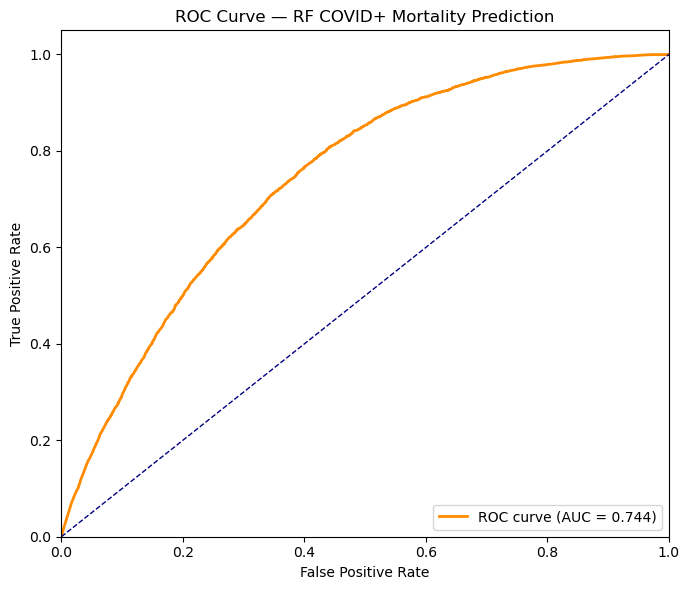

In [17]:
#Imports
from sklearn.metrics import roc_curve, auc

fpr_pos, tpr_pos, _ = roc_curve(y_test_pos, y_proba_pos)
roc_auc_pos = auc(fpr_pos, tpr_pos)

plt.figure(figsize=(7, 6))
plt.plot(fpr_pos, tpr_pos, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_pos:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — RF COVID+ Mortality Prediction')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_pos.png", dpi=150)
plt.show()

#### 5.2.2 COVID-negative

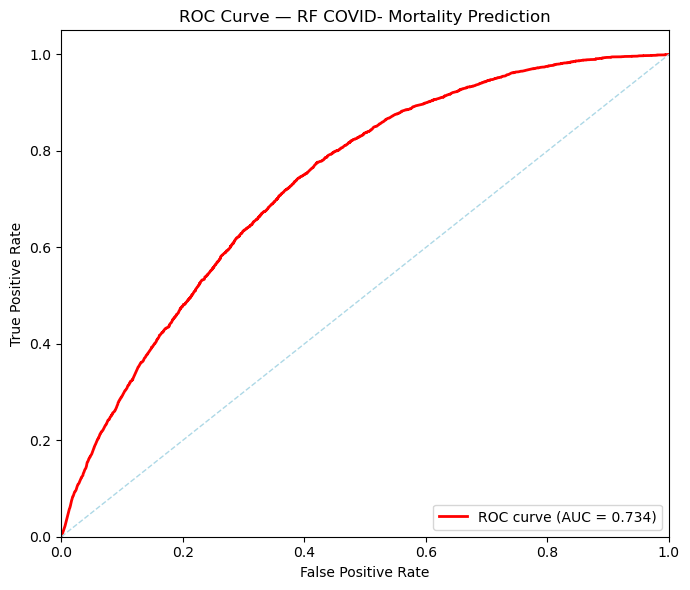

In [18]:
fpr_neg, tpr_neg, _ = roc_curve(y_test_neg, y_proba_neg)
roc_auc_neg = auc(fpr_neg, tpr_neg)

plt.figure(figsize=(7, 6))
plt.plot(fpr_neg, tpr_neg, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc_neg:.3f})')
plt.plot([0, 1], [0, 1], color='lightblue', linestyle='--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — RF COVID- Mortality Prediction')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_neg.png", dpi=150)
plt.show()

### 5.3 Precision-Recall Curve

The Precision-Recall curve  plots precision against recall across all thresholds, with the average precision (AP) score summarising the area underneath. A model with no skill would achieve a precision equal to the proportion of positive cases in the dataset (~0.22 for COVID-positive). Any AP meaningfully above this baseline indicates predictive power.

#### 5.3.1 COVID-positive

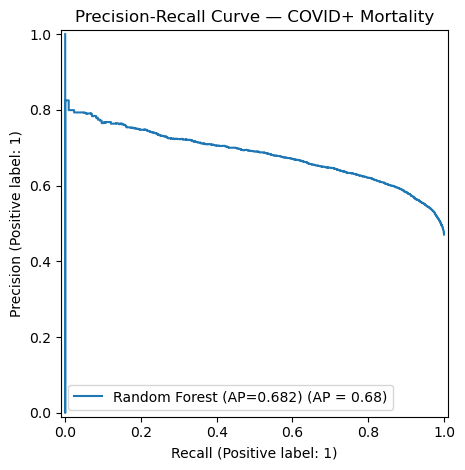

In [19]:
#Imports
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

ap_rf_pos = average_precision_score(y_test_pos, y_proba_pos)
PrecisionRecallDisplay.from_predictions(y_test_pos, y_proba_pos, name=f"Random Forest (AP={ap_rf_pos:.3f})")
plt.title("Precision-Recall Curve — COVID+ Mortality")
plt.tight_layout()
plt.savefig("pr_curve_pos.png", dpi=150)
plt.show()

#### 5.3.2 COVID-negative

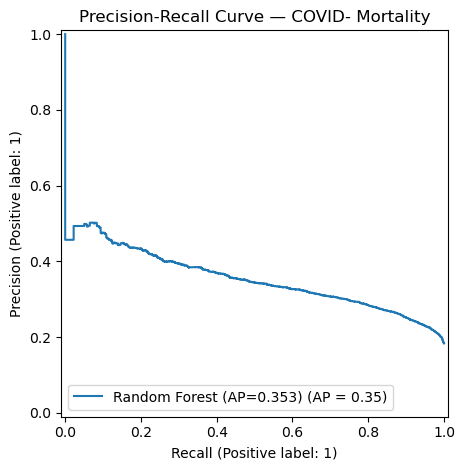

In [20]:
ap_rf_neg = average_precision_score(y_test_neg, y_proba_neg)
PrecisionRecallDisplay.from_predictions(y_test_neg, y_proba_neg, name=f"Random Forest (AP={ap_rf_neg:.3f})")
plt.title("Precision-Recall Curve — COVID- Mortality")
plt.tight_layout()
plt.savefig("pr_curve_neg.png", dpi=150)
plt.show()

### 5.4 Confusion Matrix

The confusion matrix shows the counts of correct and incorrect predictions broken down by class:
- **True Negatives (top-left):** patients who survived and were correctly predicted to survive
- **False Positives (top-right):** patients who survived but were incorrectly predicted to die
- **False Negatives (bottom-left):** patients who died but were incorrectly predicted to survive — the most clinically costly error
- **True Positives (bottom-right):** patients who died and were correctly predicted to die

Here, TP is on the bottom-right, because we're trying to predict mortality.

The relatively high false positive count is a deliberate consequence of class_weight="balanced". The model is tuned to minimise missed deaths at the cost of more false alarms.

#### 5.4.1 COVID-positive

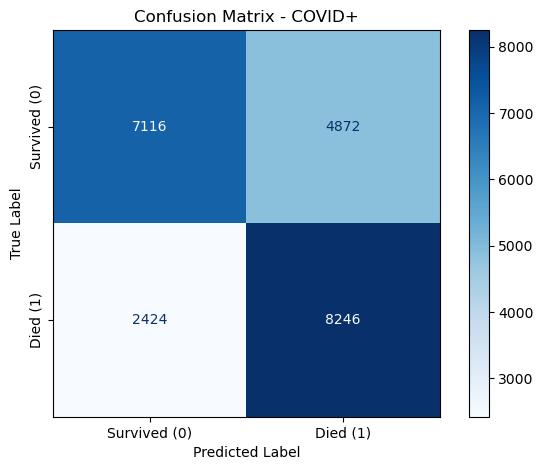

In [21]:
#Imports
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_pos = confusion_matrix(y_test_pos, y_pred_pos)
disp_pos = ConfusionMatrixDisplay(confusion_matrix=cm_pos, display_labels=["Survived (0)", "Died (1)"])
disp_pos.plot(cmap="Blues")
plt.title("Confusion Matrix - COVID+")
plt.yticks(rotation=90, va="center")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_pos.png", dpi=150)
plt.show()

#### 5.4.2 COVID-negative

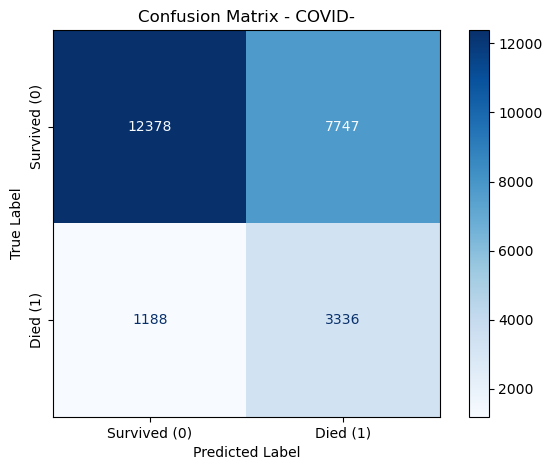

In [22]:
cm_neg = confusion_matrix(y_test_neg, y_pred_neg)
disp_neg = ConfusionMatrixDisplay(confusion_matrix=cm_neg, display_labels=["Survived (0)", "Died (1)"])
disp_neg.plot(cmap="Blues")
plt.title("Confusion Matrix - COVID-")
plt.yticks(rotation=90, va="center") #or rotation=90
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_neg.png", dpi=150)
plt.show()

## 6. Interpretation

### 6.1 Feature Importance (Gini)

Gini feature importance measures how much each feature reduces impurity (disorder) across all splits in all trees, averaged over the entire forest. Features that appear higher in trees and produce cleaner splits receive higher importance scores. Values are normalised to sum to 1.

Gini importance can slightly overrate continuous features like AGE (which has many possible split points) relative to binary features. Permutation importance in the next section corrects for this.

#### 6.1.1 COVID-positive

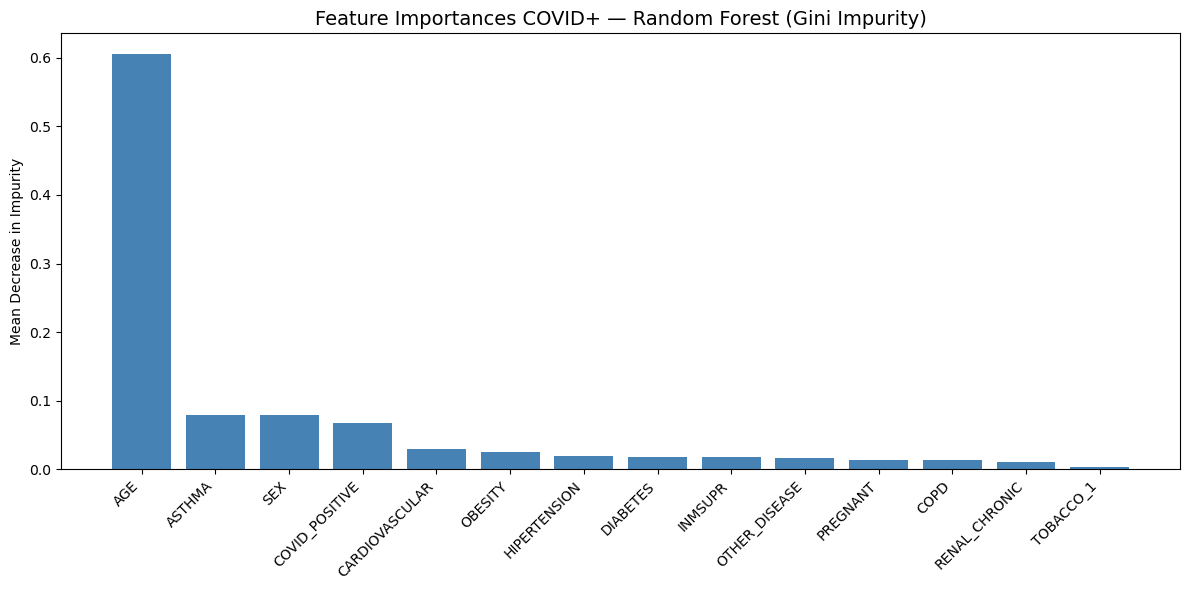


Feature ranking:
 1. AGE                  0.6052
 2. ASTHMA               0.0798
 3. SEX                  0.0787
 4. COVID_POSITIVE       0.0670
 5. CARDIOVASCULAR       0.0292
 6. OBESITY              0.0258
 7. HIPERTENSION         0.0196
 8. DIABETES             0.0183
 9. INMSUPR              0.0180
10. OTHER_DISEASE        0.0162
11. PREGNANT             0.0141
12. COPD                 0.0135
13. RENAL_CHRONIC        0.0114
14. TOBACCO_1            0.0034


In [23]:
# Get feature importances from the best model
importances_pos = best_model_pos.feature_importances_
feature_names_pos = X_pos.columns
indices_pos = np.argsort(importances_pos)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances COVID+ — Random Forest (Gini Impurity)", fontsize=14)
plt.bar(range(len(importances_pos)), importances_pos[indices_pos], color="steelblue")
plt.xticks(range(len(importances_pos)), [feature_names_pos[i] for i in indices_pos], rotation=45, ha='right')
plt.ylabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("feature_importance_pos.png", dpi=150)
plt.show()

# Print ranked table
print("\nFeature ranking:")
for rank, i in enumerate(indices_pos):
    print(f"{rank+1:2d}. {feature_names_pos[i]:<20s} {importances_pos[i]:.4f}")

#### 6.1.2 COVID-negative

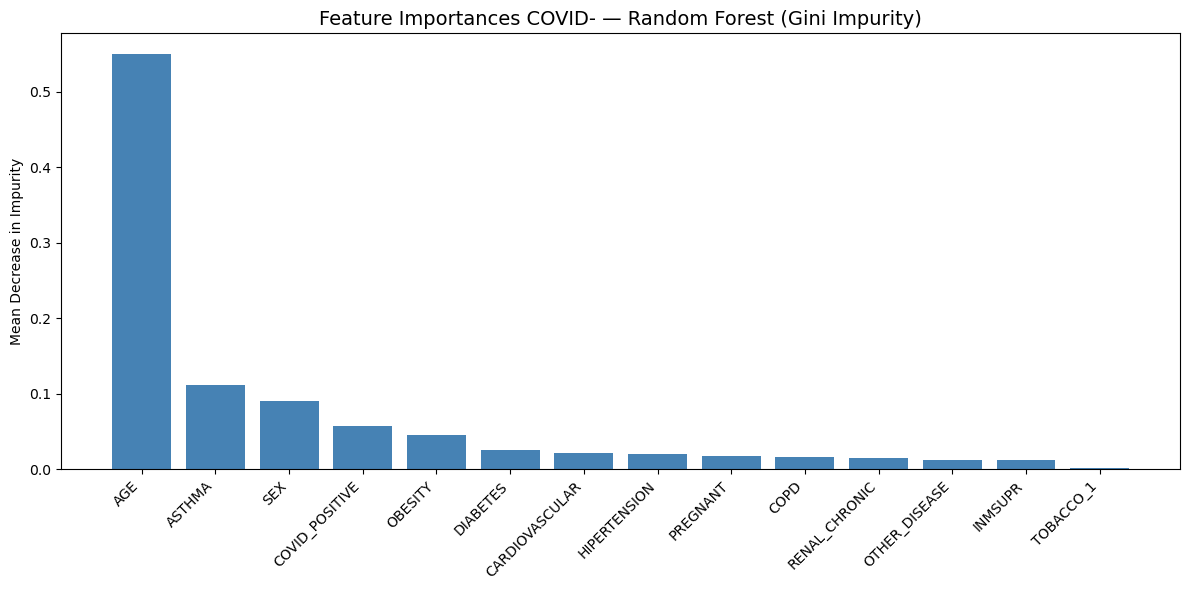


Feature ranking:
 1. AGE                  0.5499
 2. ASTHMA               0.1124
 3. SEX                  0.0905
 4. COVID_POSITIVE       0.0577
 5. OBESITY              0.0456
 6. DIABETES             0.0251
 7. CARDIOVASCULAR       0.0220
 8. HIPERTENSION         0.0201
 9. PREGNANT             0.0176
10. COPD                 0.0167
11. RENAL_CHRONIC        0.0147
12. OTHER_DISEASE        0.0128
13. INMSUPR              0.0128
14. TOBACCO_1            0.0021


In [24]:
# Get feature importances from the best model
importances_neg = best_model_neg.feature_importances_
feature_names_neg = X_neg.columns
indices_neg = np.argsort(importances_neg)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances COVID- — Random Forest (Gini Impurity)", fontsize=14)
plt.bar(range(len(importances_neg)), importances_neg[indices_neg], color="steelblue")
plt.xticks(range(len(importances_neg)), [feature_names_neg[i] for i in indices_neg], rotation=45, ha='right')
plt.ylabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("feature_importance_neg.png", dpi=150)
plt.show()

# Print ranked table
print("\nFeature ranking:")
for rank, i in enumerate(indices_neg):
    print(f"{rank+1:2d}. {feature_names_neg[i]:<20s} {importances_neg[i]:.4f}")

### 6.2 Permutation Importance

Permutation importance measures how much the model's ROC-AUC drops when a single feature's values are randomly shuffled across all test patients, and thus destroying its real relationship with mortality. A large drop indicates the model genuinely depends on that feature for accurate predictions. 

This is a more reliable measure than Gini importance because it is evaluated on the held-out test set and is not biased by feature type or number of unique values. The boxplot shows the distribution of importance across 10 repeated shuffles, with the spread indicating how stable the estimate is.

#### 6.2.1 COVID-positive

/var/folders/38/xxcq7jhd6xdfz8k26h24h2k40000gn/T/ipykernel_18262/2329830900.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_pos.importances[perm_indices_pos].T,


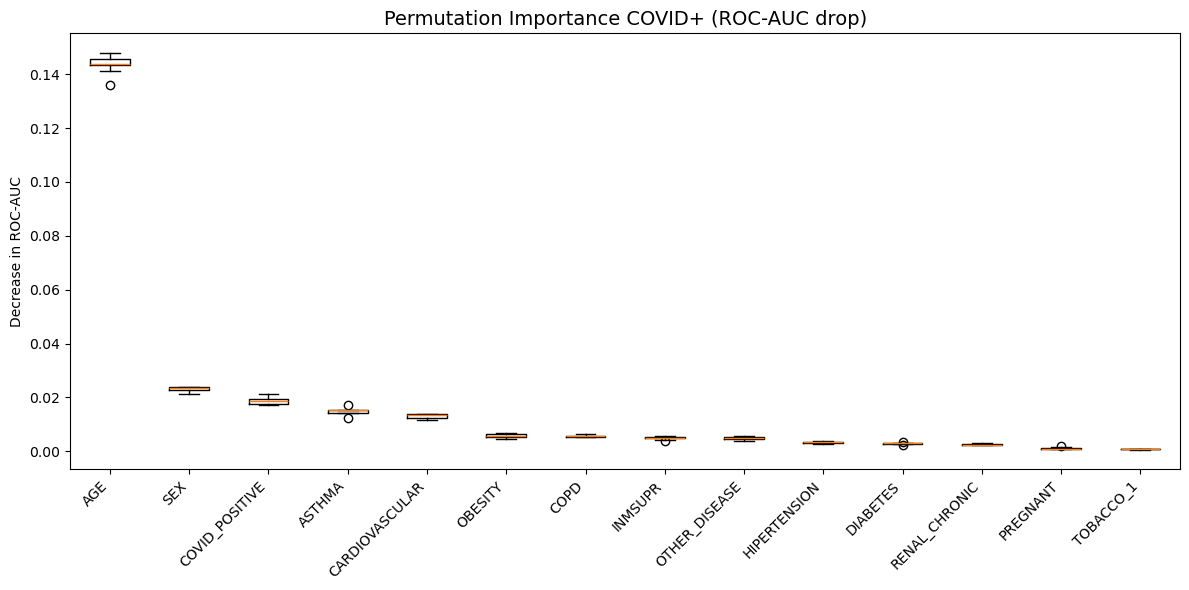

In [25]:
#Imports
from sklearn.inspection import permutation_importance

perm_pos = permutation_importance(best_model_pos, X_test_pos, y_test_pos, 
                               n_repeats=10, random_state=42, 
                               scoring='roc_auc', n_jobs=-1)

perm_indices_pos = np.argsort(perm_pos.importances_mean)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Permutation Importance COVID+ (ROC-AUC drop)", fontsize=14)
plt.boxplot(perm_pos.importances[perm_indices_pos].T, 
            labels=[feature_names_pos[i] for i in perm_indices_pos], 
            vert=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Decrease in ROC-AUC")
plt.tight_layout()
plt.savefig("permutation_importance_pos.png", dpi=150)
plt.show()

#### 6.2.2 COVID-negative

/var/folders/38/xxcq7jhd6xdfz8k26h24h2k40000gn/T/ipykernel_18262/1921738287.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_neg.importances[perm_indices_neg].T,


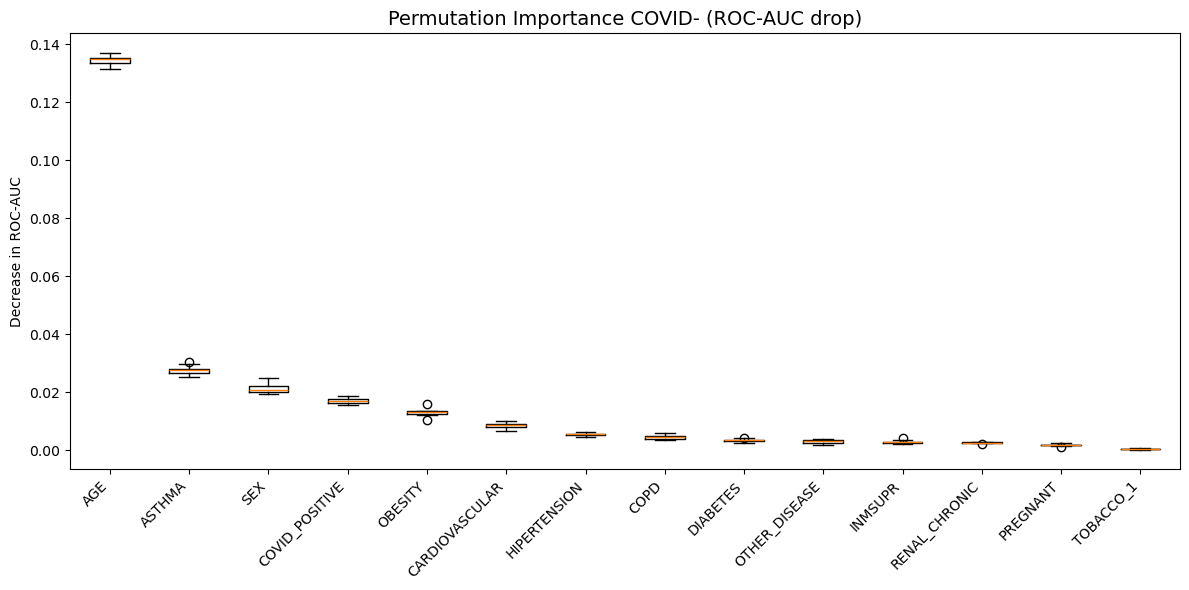

In [26]:
perm_neg = permutation_importance(best_model_neg, X_test_neg, y_test_neg, 
                               n_repeats=10, random_state=42, 
                               scoring='roc_auc', n_jobs=-1)

perm_indices_neg = np.argsort(perm_neg.importances_mean)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Permutation Importance COVID- (ROC-AUC drop)", fontsize=14)
plt.boxplot(perm_neg.importances[perm_indices_neg].T, 
            labels=[feature_names_neg[i] for i in perm_indices_neg], 
            vert=True)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Decrease in ROC-AUC")
plt.tight_layout()
plt.savefig("permutation_importance_neg.png", dpi=150)
plt.show()

### 6.3 Threshold optimisation

By default, the model classifies a patient as "Died" when the predicted probability exceeds 0.5. However, in a medical screening context, missing a death (false negative) is far more harmful than a false alarm (false positive). 

The optimal threshold is found by maximising the F2-score, a variant of F1 that weights recall twice as heavily as precision. The manual threshold comparison then shows the explicit precision/recall tradeoff at four candidate thresholds.

#### 6.3.1 COVID-positive

In [27]:
from sklearn.metrics import fbeta_score

thresholds_pos = np.arange(0.1, 0.9, 0.01)
f2_scores_pos = [fbeta_score(y_test_pos, (y_proba_pos >= t).astype(int), beta=2) for t in thresholds_pos]

best_thresh_pos = thresholds_pos[np.argmax(f2_scores_pos)]
print(f"Optimal threshold (F2) COVID+: {best_thresh_pos:.2f}")

y_pred_optimised_pos = (y_proba_pos >= best_thresh_pos).astype(int)
print("\nClassification Report (optimised threshold) COVID+:")
print(classification_report(y_test_pos, y_pred_optimised_pos, target_names=["Survived", "Died"]))

Optimal threshold (F2) COVID+: 0.23

Classification Report (optimised threshold) COVID+:
              precision    recall  f1-score   support

    Survived       0.91      0.23      0.37     11988
        Died       0.53      0.97      0.69     10670

    accuracy                           0.58     22658
   macro avg       0.72      0.60      0.53     22658
weighted avg       0.73      0.58      0.52     22658



In [28]:
# Manual threshold for better precision/recall balance
from sklearn.metrics import recall_score, precision_score

for t in [0.35, 0.40, 0.45, 0.50]:
    y_temp_pos = (y_proba_pos >= t).astype(int)
    print(f"Threshold {t:.2f} — Recall: {recall_score(y_test_pos, y_temp_pos):.2f}, Precision: {precision_score(y_test_pos, y_temp_pos):.2f}")

Threshold 0.35 — Recall: 0.92, Precision: 0.57
Threshold 0.40 — Recall: 0.89, Precision: 0.59
Threshold 0.45 — Recall: 0.84, Precision: 0.61
Threshold 0.50 — Recall: 0.77, Precision: 0.63


#### 6.3.2 COVID-negative

In [29]:
thresholds_neg = np.arange(0.1, 0.9, 0.01)
f2_scores_neg = [fbeta_score(y_test_neg, (y_proba_neg >= t).astype(int), beta=2) for t in thresholds_neg]

best_thresh_neg = thresholds_neg[np.argmax(f2_scores_neg)]
print(f"Optimal threshold (F2) COVID-: {best_thresh_neg:.2f}")

y_pred_optimised_neg = (y_proba_neg >= best_thresh_neg).astype(int)
print("\nClassification Report (optimised threshold) COVID-:")
print(classification_report(y_test_neg, y_pred_optimised_neg, target_names=["Survived", "Died"]))

Optimal threshold (F2) COVID-: 0.37

Classification Report (optimised threshold) COVID-:
              precision    recall  f1-score   support

    Survived       0.94      0.45      0.61     20125
        Died       0.26      0.88      0.40      4524

    accuracy                           0.53     24649
   macro avg       0.60      0.66      0.51     24649
weighted avg       0.82      0.53      0.57     24649



In [30]:
# Manual threshold for better precision/recall balance
for t in [0.35, 0.40, 0.45, 0.50]:
    y_temp_neg = (y_proba_neg >= t).astype(int)
    print(f"Threshold {t:.2f} — Recall: {recall_score(y_test_neg, y_temp_neg):.2f}, Precision: {precision_score(y_test_neg, y_temp_neg):.2f}")

Threshold 0.35 — Recall: 0.90, Precision: 0.25
Threshold 0.40 — Recall: 0.84, Precision: 0.27
Threshold 0.45 — Recall: 0.80, Precision: 0.28
Threshold 0.50 — Recall: 0.74, Precision: 0.30


### 6.4 SHAP

SHAP quantifies each feature's contribution to individual predictions using game-theoretic principles. Unlike feature importance, SHAP shows not just which features matter but in which direction, like for example: Does having diabetes push a patient toward death or survival, and by how much?

- **Beeswarm plot:** each dot is one patient. Position on the x-axis shows whether that feature pushed the prediction toward death (positive) or survival (negative). The colour shows the feature value (red = high, blue = low).
- **Bar chart:** mean absolute SHAP value per feature, the ranking of feature importance across all patients.

SHAP directly answers the research question: which pre-existing risk factors are most strongly associated with COVID mortality

#### 6.4.1 COVID-positive

/opt/miniconda3/envs/jupyter-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


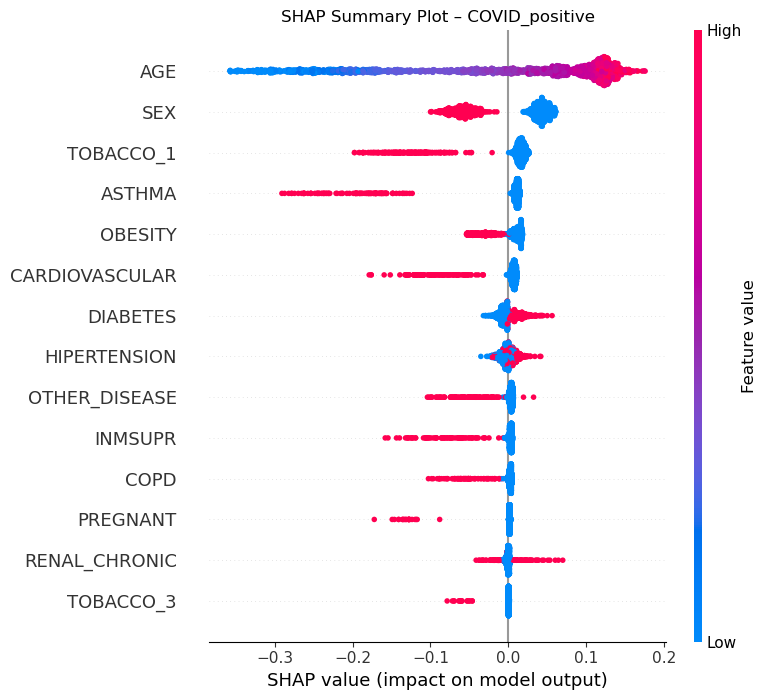

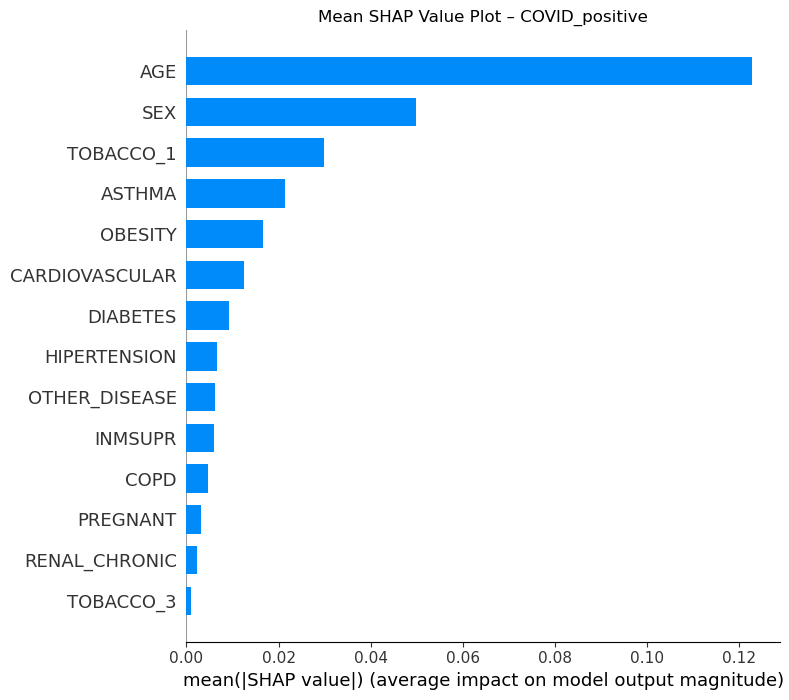

In [31]:
#Imports
import shap

explainer_pos = shap.TreeExplainer(best_model_pos)
# Use a sample for speed (SHAP on 95k rows is slow)
X_sample_pos = X_test_pos.sample(2000, random_state=42)
shap_values_pos = explainer_pos.shap_values(X_sample_pos)

# Beeswarm plot — shows direction of effect per patient
shap.summary_plot(shap_values_pos[:, :, 1], X_sample_pos, show=False)
plt.title("SHAP Summary Plot – COVID_positive")
plt.tight_layout()
plt.savefig("shap_beeswarm_pos.png", dpi=150)
plt.show()

# Summary plot — shows which features push toward death (class 1)
shap.summary_plot(shap_values_pos[:, :, 1], X_sample_pos, plot_type="bar",
                  show=False)
plt.title("Mean SHAP Value Plot – COVID_positive")
plt.tight_layout()
plt.savefig("shap_importance_pos.png", dpi=150)
plt.show()

#### 6.4.2 COVID-negative

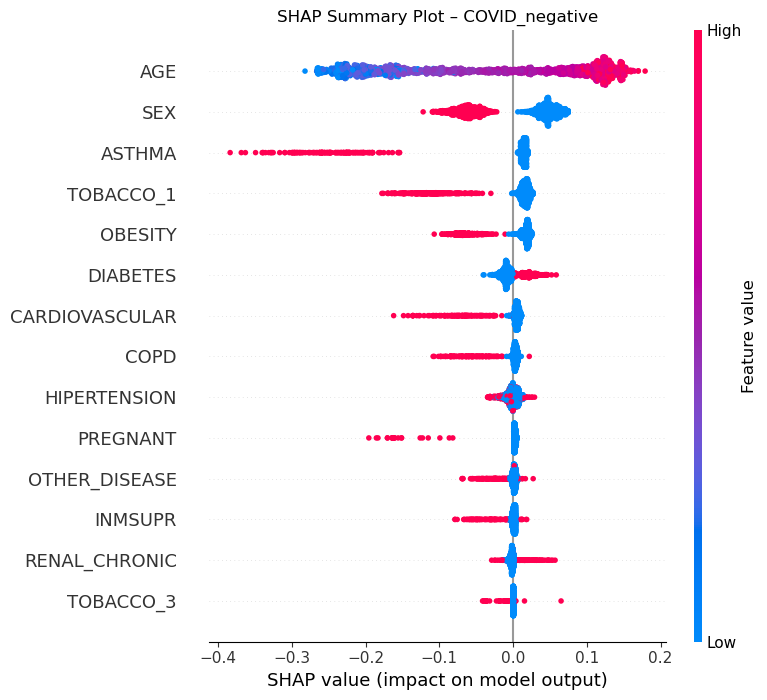

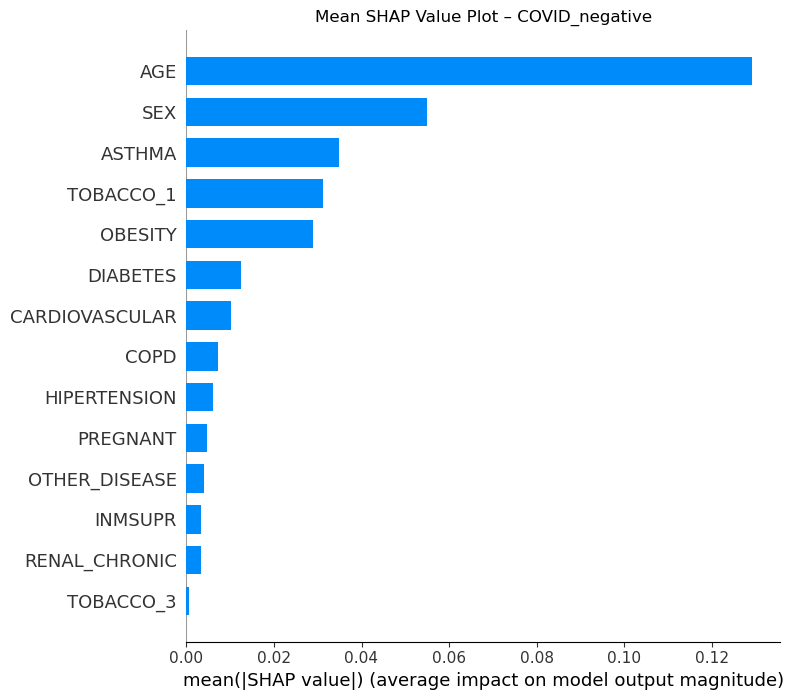

In [32]:
explainer_neg = shap.TreeExplainer(best_model_neg)
# Use a sample for speed (SHAP on 95k rows is slow)
X_sample_neg = X_test_neg.sample(2000, random_state=42)
shap_values_neg = explainer_neg.shap_values(X_sample_neg)

# Beeswarm plot — shows direction of effect per patient
shap.summary_plot(shap_values_neg[:, :, 1], X_sample_neg, show=False)
plt.title("SHAP Summary Plot – COVID_negative")
plt.tight_layout()
plt.savefig("shap_beeswarm_neg.png", dpi=150)
plt.show()

# Summary plot — shows which features push toward death (class 1)
shap.summary_plot(shap_values_neg[:, :, 1], X_sample_neg, plot_type="bar",
                  show=False)
plt.title("Mean SHAP Value Plot – COVID_negative")
plt.tight_layout()
plt.savefig("shap_importance_neg.png", dpi=150)
plt.show()

### 6.5 Bootstrap Confidence Intervals

A single ROC-AUC score computed on one test set holds a certain sampling uncertainty. A slightly different random split would produce a slightly different score. Bootstrap confidence intervals quantify this uncertainty by resampling the test set 1000 times with replacement and computing ROC-AUC each time. The 95% confidence interval contains the true population AUC with 95% probability, giving a more statistically rigorous performance estimate than a single point value.

#### 6.5.1 COVID-positive

In [33]:
#Imports
from sklearn.utils import resample

n_bootstraps_pos = 1000
roc_scores_pos = []
for _ in range(n_bootstraps_pos):
    idx_pos = resample(range(len(y_test_pos)), random_state=None)
    if len(np.unique(np.array(y_test_pos)[idx_pos])) < 2:
        continue
    roc_scores_pos.append(roc_auc_score(np.array(y_test_pos)[idx_pos], np.array(y_proba_pos)[idx_pos]))

print(f"ROC-AUC COVID+: {np.mean(roc_scores_pos):.3f} "
      f"(95% CI COVID+: {np.percentile(roc_scores_pos, 2.5):.3f}–{np.percentile(roc_scores_pos, 97.5):.3f})")

ROC-AUC COVID+: 0.744 (95% CI COVID+: 0.738–0.750)


#### 6.5.2 COVID-negative

In [34]:
n_bootstraps_neg = 1000
roc_scores_neg = []
for _ in range(n_bootstraps_neg):
    idx_neg = resample(range(len(y_test_neg)), random_state=None)
    if len(np.unique(np.array(y_test_neg)[idx_neg])) < 2:
        continue
    roc_scores_neg.append(roc_auc_score(np.array(y_test_neg)[idx_neg], np.array(y_proba_neg)[idx_neg]))

print(f"ROC-AUC COVID-: {np.mean(roc_scores_neg):.3f} "
      f"(95% CI COVID-: {np.percentile(roc_scores_neg, 2.5):.3f}–{np.percentile(roc_scores_neg, 97.5):.3f})")

ROC-AUC COVID-: 0.734 (95% CI COVID-: 0.727–0.742)


### 6.6 Calibration Curve

A calibration curve tests whether the model's predicted probabilities reflect actual observed mortality rates. A perfectly calibrated model would follow the diagonal, for example, when it predicts a 70% chance of death, approximately 70% of those patients should actually die.

Random Forests are usually systematically overconfident (predicted probabilities tend to be pushed toward extremes), which is reflected in the curve falling below the diagonal. This is why threshold optimisation rather than raw probability cutoffs was used for the final classification decision.

#### 6.6.1 COVID-positive

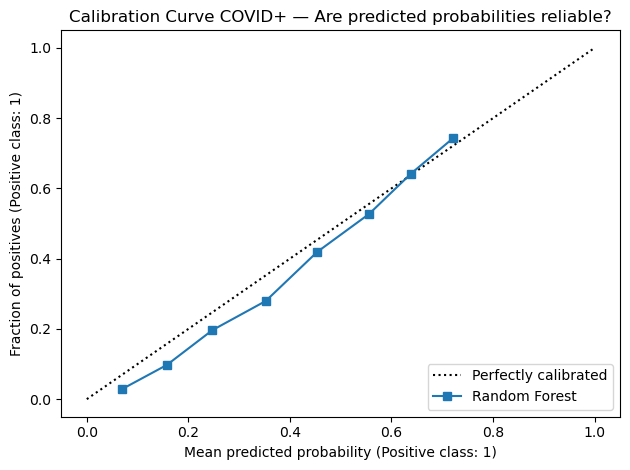

In [35]:
#Imports
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test_pos, y_proba_pos, n_bins=10, name="Random Forest")
plt.title("Calibration Curve COVID+ — Are predicted probabilities reliable?")
plt.tight_layout()
plt.savefig("calibration_curve_pos.png", dpi=150)
plt.show()

#### 6.6.2 COVID-negative

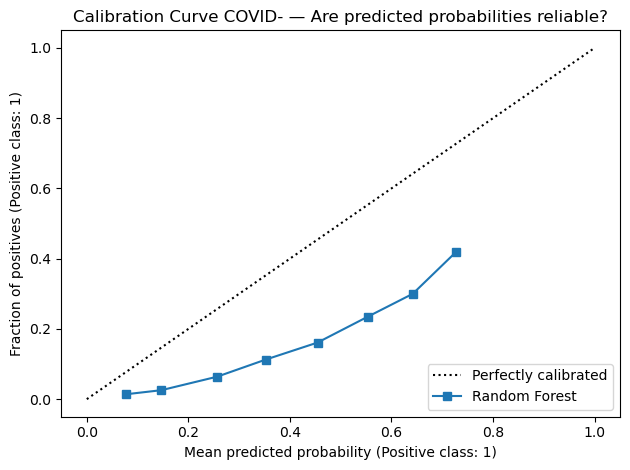

In [36]:
CalibrationDisplay.from_predictions(y_test_neg, y_proba_neg, n_bins=10, name="Random Forest")
plt.title("Calibration Curve COVID- — Are predicted probabilities reliable?")
plt.tight_layout()
plt.savefig("calibration_curve_neg.png", dpi=150)
plt.show()